In [3]:
from PIL import Image
import pandas as pd

In [8]:
labels = {1: "meningioma", 2 : "glioma", 3 : "pituitary tumor"}

meningioma


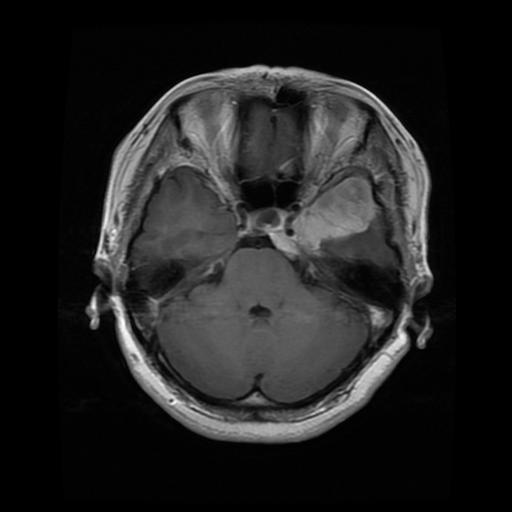

In [22]:
print(labels[1])
img_1 = Image.open('./data_jpg/1/1.jpg')
img_1

glioma


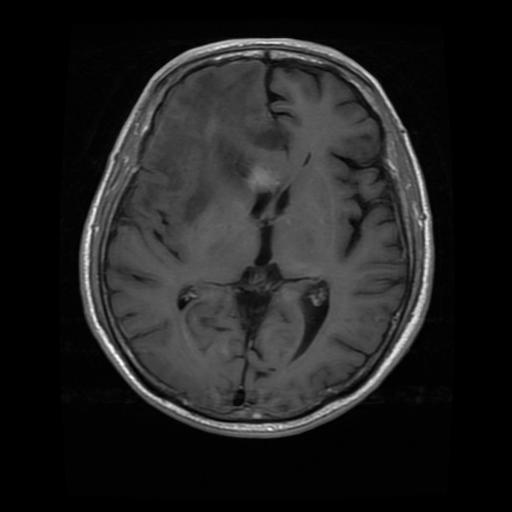

In [23]:
print(labels[2])
img_2 = Image.open('./data_jpg/2/209.jpg')
img_2

pituitary tumor


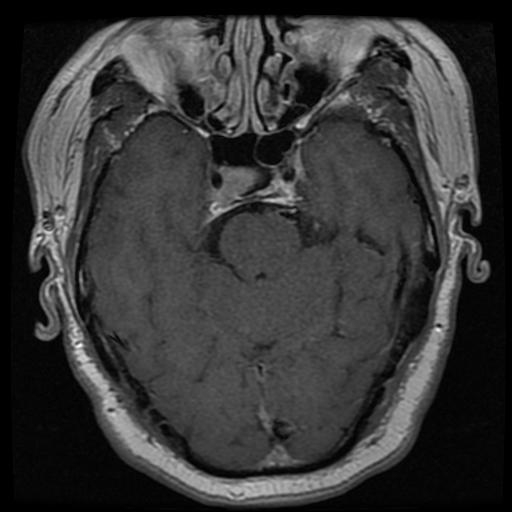

In [24]:
print(labels[3])
img_3 = Image.open('./data_jpg/3/709.jpg')
img_3

In [25]:
import os

dir_path = './data_jpg/1'
count = sum(1 for f in os.listdir(dir_path) if os.path.isfile(os.path.join(dir_path, f)))
print('File count 1:', count)   

File count 1: 708


In [26]:
import os

dir_path = './data_jpg/2'
count = sum(1 for f in os.listdir(dir_path) if os.path.isfile(os.path.join(dir_path, f)))
print('File count 2:', count)   

File count 2: 1426


In [27]:
import os

dir_path = './data_jpg/3'
count = sum(1 for f in os.listdir(dir_path) if os.path.isfile(os.path.join(dir_path, f)))
print('File count 3:', count)   

File count 3: 930


In [28]:
import torch
import torch.nn
import torch.nn.functional as F

from torchvision import transforms

In [41]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [42]:
t = transforms.ToTensor()
img3_tensor = t(img_3)
img3_tensor

tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]])

In [43]:
img3_tensor.shape

torch.Size([1, 512, 512])

In [44]:
print(t(img_2).shape)
t(img_2)

torch.Size([1, 512, 512])


tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]])

In [45]:
print(t(img_1).shape)
t(img_1)

torch.Size([1, 512, 512])


tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]])

In [47]:
img3_tensor = img3_tensor.to(device)
img3_tensor

tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]], device='cuda:0')

In [6]:
df = pd.read_csv('validation_results.csv')

In [9]:
patient_slices = df[df['PID'] == '114094'].sort_values('source_file')
patient_slices[['filename', 'true_label', 'pred_label', 'confidence', 'tumor_area', 'correct']]

,filename,true_label,pred_label,confidence,tumor_area,correct
151,1021.jpg,2,2,0.999999,4938,True
195,1022.jpg,1,1,0.999995,3610,True
213,1023.jpg,2,2,0.999992,3635,True
1,1024.jpg,2,2,1.000000,2005,True
2,1161.jpg,2,2,1.000000,3201,True
102,1162.jpg,1,1,1.000000,4047,True
7,1163.jpg,1,1,1.000000,4380,True
322,1164.jpg,1,1,0.999061,6072,True
5,1165.jpg,2,2,1.000000,5292,True
4,1279.jpg,1,1,1.000000,5118,True
